# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


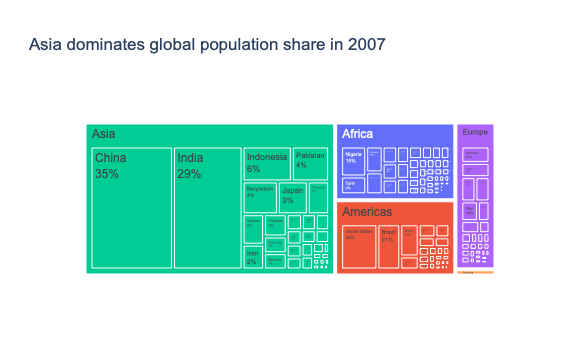

In [4]:
df = px.data.gapminder().query("year == 2007")

fig1 = px.treemap(
    df,
    path=['continent', 'country'],
    values='pop',
    color='continent',
    title='Asia dominates global population share in 2007'
)

fig1.update_traces(
    textinfo='label+percent parent'
)

fig1.update_layout(
    font_family='Arial',
    paper_bgcolor='white'
)

fig1.show()



## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


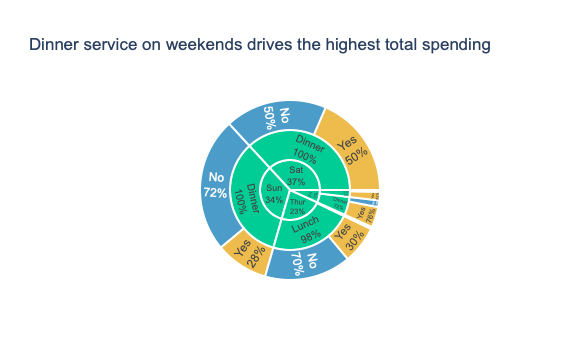

In [5]:
tips = px.data.tips()

# Aggregate total bill
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

fig2 = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#E69F00',   # orange
        'No': '#0072B2'     # blue
    },
    title='Dinner service on weekends drives the highest total spending'
)

# Grey out parent nodes
fig2.update_traces(
    marker=dict(
        line=dict(color='white', width=2)
    ),
    textinfo='label+percent parent'
)

fig2.update_layout(
    font_family='Arial',
    paper_bgcolor='white'
)

fig2.show()



## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


In [6]:
energy = pd.DataFrame({
    'Country': ['France', 'Canada', 'Brazil', 'China', 'USA', 'Sweden'],
    'Nuclear': [379, 95, 15, 407, 775, 50],
    'Hydro': [70, 383, 410, 1300, 250, 65]
})

# Create total low-carbon TWh
energy['TWh'] = energy['Nuclear'] + energy['Hydro']
energy['Source_Type'] = 'Low-carbon'

low_carbon = (
    energy.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Dummy root node
low_carbon['All'] = 'Low-carbon'


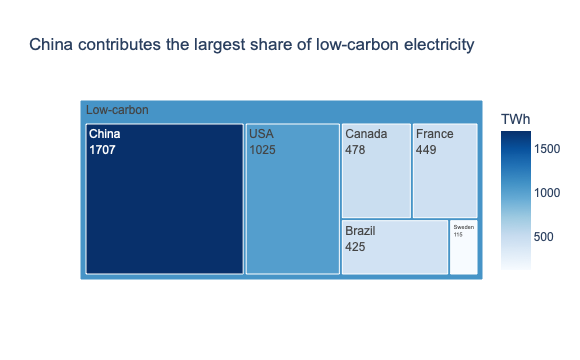

In [7]:
fig3 = px.treemap(
    low_carbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='China contributes the largest share of low-carbon electricity'
)

fig3.update_traces(
    textinfo='label+value'
)

fig3.update_layout(
    font_family='Arial',
    paper_bgcolor='white'
)

fig3.show()



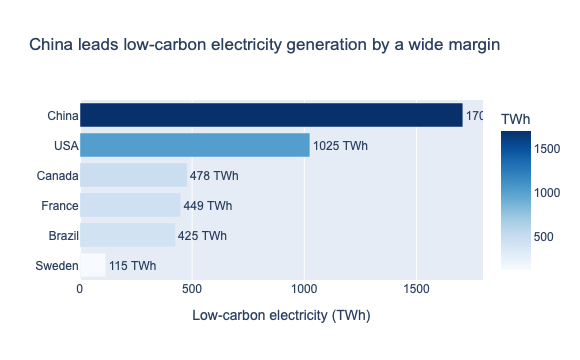

In [8]:
low_carbon_sorted = low_carbon.sort_values('TWh')

fig4 = px.bar(
    low_carbon_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    title='China leads low-carbon electricity generation by a wide margin'
)

fig4.update_traces(
    texttemplate='%{x} TWh',
    textposition='outside'
)

fig4.update_layout(
    font_family='Arial',
    paper_bgcolor='white',
    showlegend=False,
    xaxis_title='Low-carbon electricity (TWh)',
    yaxis_title=''
)

fig4.show()

The horizontal bar chart is clearer for comparing exact country values because the aligned axis makes differences easier to judge accurately.

The treemap is more useful for showing proportional contribution to the whole, but smaller differences between countries are harder to compare visually.